In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 회귀용
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier


# 학습 모델 저장을 위한 라이브러리
import pickle

In [2]:
df = pd.read_csv('/Users/hapresent/Desktop/11_파이널프로젝트관련/open/07.09/컬럼중요도30개 선택.csv')

In [3]:
df

,ID,Segment,카드이용한도금액,정상청구원금_B0M,입회경과개월수_신용,이용금액_R3M_신용체크,_1순위카드이용금액,최대이용금액_일시불_R12M,정상입금원금_B0M,이용금액대,...,CL이자율_할인전,_2순위쇼핑업종_이용금액,_1순위업종_이용금액,이용금액_할부_무이자_R3M,이용금액_할부_무이자_B0M,CA이자율_할인전,잔액_할부_B0M,_2순위업종_이용금액,ID.1,최종이용일자_체크
0,TRAIN_000000,D,19354,14440,67,196,3681,4906,6335,01.100만원+,...,18.254978,0,1928,1984,0,22.995207,962,1408,TRAIN_000000,20180203
1,TRAIN_000001,E,9996,6024,12,13475,13323,10407,5198,03.30만원+,...,14.834873,435,2158,0,0,14.793821,2390,2083,TRAIN_000001,10101
2,TRAIN_000002,C,88193,21929,124,23988,24493,10112,12564,01.100만원+,...,17.875321,1038,16924,11308,0,22.014276,5113,1539,TRAIN_000002,20141230
3,TRAIN_000003,D,19062,18563,27,3904,5933,3075,7639,01.100만원+,...,22.999453,487,2405,5643,0,22.998014,5025,2284,TRAIN_000003,20141111
4,TRAIN_000004,E,177222,0,2,1190,0,62,0,09.미사용,...,10.897410,0,0,0,0,14.661948,0,0,TRAIN_000004,20180512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,TRAIN_399995,E,20070,19,209,10755,5640,0,0,09.미사용,...,11.900516,0,0,0,0,15.243670,0,0,TRAIN_399995,20181212
2399996,TRAIN_399996,D,84217,13462,17,27636,26357,47684,9705,01.100만원+,...,15.652063,714,5608,0,0,14.843464,0,1810,TRAIN_399996,10101
2399997,TRAIN_399997,C,52612,7049,115,23187,17171,10212,5346,02.50만원+,...,17.966213,400,3634,0,0,17.038599,2960,2315,TRAIN_399997,20131124
2399998,TRAIN_399998,E,10002,0,71,0,0,0,0,09.미사용,...,11.901089,0,0,0,0,15.182880,0,0,TRAIN_399998,10101


In [4]:
df.columns

Index(['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', 'ID.1', '최종이용일자_체크'],
      dtype='object')

In [5]:
df['ID'].equals(df['ID.1'])

True

In [6]:
#중복 컬럼을 제거한다
df = df.drop(columns=['ID.1'])

### Frequency를 나타내는 컬럼 '_1순위카드이용건수'를 추가하자 

In [8]:
#데이터 불러오기 

In [9]:
# df1 = pd.read_csv('/Users/hapresent/Desktop/11_파이널프로젝트관련/open/07.09/01_회원정보_selected (1).csv')

In [10]:
# df1.columns

In [11]:
# df1

In [12]:
# #두 데이터 병합하기 
# df1['ID'] = df['ID']  # 병합 기준 생성 
# df1_subset = df1[['ID', '_1순위카드이용건수', '기준년월']]
# df_merged = pd.merge(df, df1_subset, on='ID', how='left')

In [13]:
# df_merged.columns #컬럼 추가 확인 완료

In [14]:
#병합한 파일 우선 저장하자 
# df_merged.to_csv('/Users/hapresent/Desktop/11_파이널프로젝트관련/open/07.09/merged_added_card_usage.csv')

In [15]:
# df_merged

## RFM 분석

In [17]:
# df = df_merged

In [18]:
# df.groupby('Segment')['_1순위카드이용건수'].mean()

In [19]:
df.columns

Index(['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크'],
      dtype='object')

In [20]:
df['Recency']= df['최종이용일자_CA'] #나중에 다시 확인 

### 2. Frequency
### 대표 컬럼: `_1순위카드이용건수`

In [22]:
# df['Frequency'] = df['_1순위카드이용건수']

In [23]:
# df['Frequency'].unique()

In [24]:
# #카드 이용건수에 음수값이 있으므로 제거한다. (이상치) 
# df = df[df['Frequency'] >= 0]

In [25]:
# df.groupby('Segment')['Frequency'].mean()

In [26]:
# 시각화

In [27]:
# import matplotlib.pyplot as plt

# # 세그먼트별 평균 Frequency 구하기
# segment_freq = df.groupby('Segment')['Frequency'].mean()

# # 시각화
# plt.figure(figsize=(8, 5))
# bars = plt.bar(segment_freq.index, segment_freq.values, color='skyblue')

# # 바 위에 값 표시
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
#              f'{yval:.1f}', ha='center', va='bottom')

# plt.title('Frequency_세그먼트별 평균_ 1순위카드이용건수_')
# plt.xlabel('Segment')
# plt.ylabel('카드이용건수 평균')
# plt.ylim(0, segment_freq.max() * 1.15)
# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.tight_layout()
# plt.show()


### => Frequency를 몇 단계로 나눌 것인가? 
- 100회 이상 구매시 high, 
- 50회 이상 100회 미만 구매시 middle, 
- 50회 미만 구매시 low

### 3. Monetary
### 대표 컬럼: `_1순위카드이용금액`

In [30]:
df['Monetary'] = df['_1순위카드이용금액']

In [31]:
df.groupby('Segment')['_1순위카드이용금액'].mean()

Segment
A    72325.240741
B    69698.909722
C    36108.012650
D    22413.433204
E     7250.044094
Name: _1순위카드이용금액, dtype: float64

In [32]:
#시각화

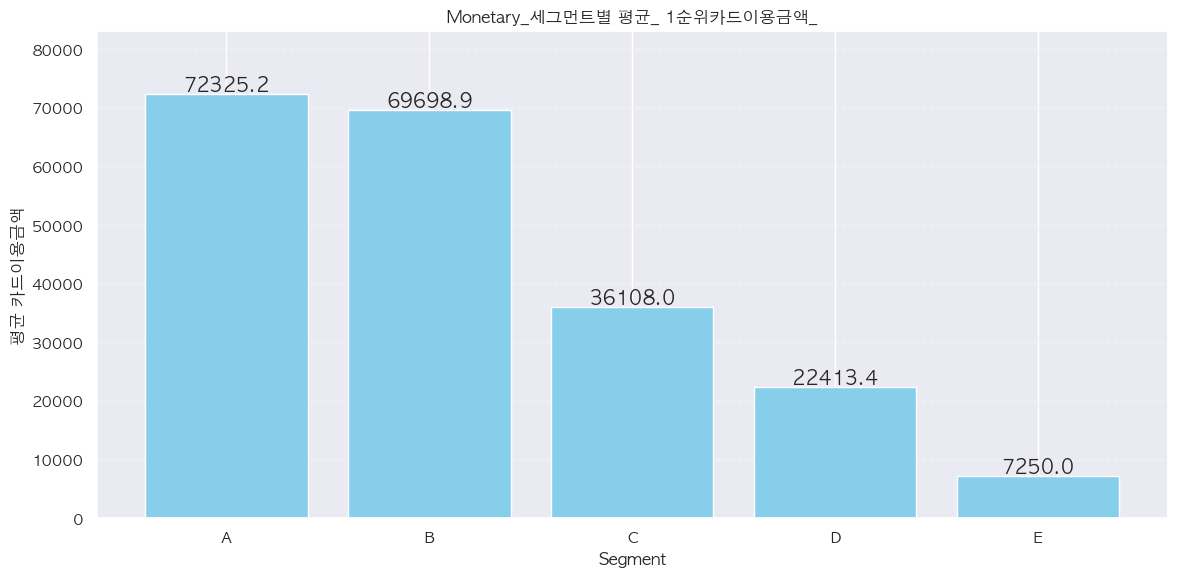

In [33]:
import matplotlib.pyplot as plt

# 세그먼트별 평균 Frequency 구하기
segment_monet = df.groupby('Segment')['Monetary'].mean()

# 시각화
plt.figure(figsize=(12, 6))
bars = plt.bar(segment_monet.index, segment_monet.values, color='skyblue')

# 바 위에 값 표시
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2,
             f'{yval:.1f}', ha='center', va='bottom')

plt.title('Monetary_세그먼트별 평균_ 1순위카드이용금액_')
plt.xlabel('Segment')
plt.ylabel('평균 카드이용금액')
plt.ylim(0, segment_monet.max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### => Monetary를 몇 단계로 나눌 것인가? 
- 이용금액이 50000 이상이면 high
- 이용금액이 15000 이상 50000 미만이면 middle
- 이용금액이 15000 미만 low 

In [35]:
### RFM 기법의 목적을 모른채 적용하려다 삽질함 - RFM은 고객 세분화를 하는데 필요한 기법임 but 우린 이미 분류가 되어있으므로 적절 X


---

### ❌ 잘못된 사용 vs ✅ 적절한 사용

| 잘못된 사용                       | 적절한 사용                                  |
| ---------------------------- | --------------------------------------- |
| A\~E 무시하고 RFM으로 새롭게 군집 나누기   | A\~E 세그먼트별로 R, F, M 평균·분포를 비교해 특성 파악    |
| RFM 점수 기준으로 전체 고객 1\~5등급 나누기 | 각 세그먼트가 얼마나 자주/많이/최근에 사용했는지 보는 데 RFM 활용 |

---

### 💡 예시로 이런 인사이트가 가능해:

* **Segment A**는 Frequency와 Monetary가 모두 높음 → **충성도 높고 가치 높은 고객**
* **Segment E**는 Recency가 길고 Frequency 낮음 → **이탈 가능성 높은 고객**
* **Segment C**는 Frequency는 낮지만 Monetary는 높음 → **고가상품 위주 구매 고객**

---




###  R, F, M을 세그먼트별로 각각 분석하기ㄱ 

In [38]:
# Recency : 얼마나 최근에 구매했는가 
# Frequency : 얼마나 자주 구매했는가 
# Monetary : 얼마나 많은 금액을 지출했는가

In [39]:
df.columns

Index(['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크', 'Recency', 'Monetary'],
      dtype='object')

# Recency

In [41]:
# 관련 컬럼: '최종이용일자_할부','최종이용일자_CA', '최종이용일자_체크'

In [136]:
df['최종이용일자_할부'].isna().sum()

666655

In [144]:
df['최종이용일자_CA'].isna().sum()

0

In [ ]:
df['최종이용일자_체크']

In [146]:
df.isna().sum()

ID                         0
Segment                    0
카드이용한도금액                   0
정상청구원금_B0M                 0
입회경과개월수_신용                 0
이용금액_R3M_신용체크              0
_1순위카드이용금액                 0
최대이용금액_일시불_R12M            0
정상입금원금_B0M                 0
이용금액대                      0
월중평잔                       0
이용금액_일시불_B0M               0
최대이용금액_할부_R12M             0
이용금액_R3M_신용                0
쇼핑_도소매_이용금액                0
이용금액_오프라인_R6M              0
이용금액_할부_R12M               0
잔액_신판ca최대한도소진율_r6m         0
최종이용일자_CA                  0
연체입금원금_B0M                 0
이용금액_CA_R12M               0
최종이용일자_할부             666655
CL이자율_할인전                  0
_2순위쇼핑업종_이용금액              0
_1순위업종_이용금액                0
이용금액_할부_무이자_R3M            0
이용금액_할부_무이자_B0M            0
CA이자율_할인전                  0
잔액_할부_B0M                  0
_2순위업종_이용금액                0
최종이용일자_체크                  0
Recency                    0
Monetary                   0
dtype: int64

In [138]:
df

,ID,Segment,카드이용한도금액,정상청구원금_B0M,입회경과개월수_신용,이용금액_R3M_신용체크,_1순위카드이용금액,최대이용금액_일시불_R12M,정상입금원금_B0M,이용금액대,...,_2순위쇼핑업종_이용금액,_1순위업종_이용금액,이용금액_할부_무이자_R3M,이용금액_할부_무이자_B0M,CA이자율_할인전,잔액_할부_B0M,_2순위업종_이용금액,최종이용일자_체크,Recency,Monetary
0,TRAIN_000000,D,19354,14440,67,196,3681,4906,6335,01.100만원+,...,0,1928,1984,0,22.995207,962,1408,20180203,20180719,3681
1,TRAIN_000001,E,9996,6024,12,13475,13323,10407,5198,03.30만원+,...,435,2158,0,0,14.793821,2390,2083,10101,20170728,13323
2,TRAIN_000002,C,88193,21929,124,23988,24493,10112,12564,01.100만원+,...,1038,16924,11308,0,22.014276,5113,1539,20141230,20180706,24493
3,TRAIN_000003,D,19062,18563,27,3904,5933,3075,7639,01.100만원+,...,487,2405,5643,0,22.998014,5025,2284,20141111,20180721,5933
4,TRAIN_000004,E,177222,0,2,1190,0,62,0,09.미사용,...,0,0,0,0,14.661948,0,0,20180512,10101,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,TRAIN_399995,E,20070,19,209,10755,5640,0,0,09.미사용,...,0,0,0,0,15.243670,0,0,20181212,10101,5640
2399996,TRAIN_399996,D,84217,13462,17,27636,26357,47684,9705,01.100만원+,...,714,5608,0,0,14.843464,0,1810,10101,10101,26357
2399997,TRAIN_399997,C,52612,7049,115,23187,17171,10212,5346,02.50만원+,...,400,3634,0,0,17.038599,2960,2315,20131124,10101,17171
2399998,TRAIN_399998,E,10002,0,71,0,0,0,0,09.미사용,...,0,0,0,0,15.182880,0,0,10101,10101,0


# Monetary

In [49]:
# 이용금액 관련 컬럼 확인하기

In [50]:
df.filter(like='이용금액')

,이용금액_R3M_신용체크,_1순위카드이용금액,최대이용금액_일시불_R12M,이용금액대,이용금액_일시불_B0M,최대이용금액_할부_R12M,이용금액_R3M_신용,쇼핑_도소매_이용금액,이용금액_오프라인_R6M,이용금액_할부_R12M,이용금액_CA_R12M,_2순위쇼핑업종_이용금액,_1순위업종_이용금액,이용금액_할부_무이자_R3M,이용금액_할부_무이자_B0M,_2순위업종_이용금액
0,196,3681,4906,01.100만원+,1995,0,196,0,11097,9431,103812,0,1928,1984,0,1408
1,13475,13323,10407,03.30만원+,2862,4607,13475,645,18638,6134,4297,435,2158,0,0,2083
2,23988,24493,10112,01.100만원+,5854,15453,23988,1038,29192,10561,374552,1038,16924,11308,0,1539
3,3904,5933,3075,01.100만원+,387,8874,3904,0,18056,22129,207745,487,2405,5643,0,2284
4,1190,0,62,09.미사용,0,0,0,0,787,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,10755,5640,0,09.미사용,0,0,7267,0,0,0,0,0,0,0,0,0
2399996,27636,26357,47684,01.100만원+,7663,2848,27636,1496,60373,1888,0,714,5608,0,0,1810
2399997,23187,17171,10212,02.50만원+,4545,15845,23187,0,32036,27617,0,400,3634,0,0,2315
2399998,0,0,0,09.미사용,0,0,0,0,0,0,0,0,0,0,0,0


| 카테고리            | 설명                 | 예시 컬럼                                       |
| --------------- | ------------------ | ------------------------------------------- |
| **① 기간 기준**     | 단기 vs 중기 vs 장기     | `_B0M` (이번 달), `_R3M` (3개월), `_R12M` (12개월) |
| **② 결제 유형**     | 일시불, 할부, 무이자       | `이용금액_일시불`, `이용금액_할부`, `무이자` 포함             |
| **③ 채널/위치**     | 오프라인, 업종별          | `이용금액_오프라인`, `1순위업종_이용금액`                   |
| **④ 카드 우선순위**   | 1순위 / 2순위          | `_1순위카드이용금액`, `_2순위업종_이용금액`                 |
| **⑤ 상품군** (있다면) | 쇼핑, 여행, 외식 등 업종 구분 | `쇼핑_도소매_이용금액` (※있다면 활용 가능)                  |


## 1. 세그먼트별 업종 카드이용금액 비교

In [53]:
card_usage = ['_1순위업종_이용금액', '_2순위업종_이용금액']

In [54]:
card_usage_mean= df.groupby('Segment')[card_usage].mean()
card_usage_mean

,_1순위업종_이용금액,_2순위업종_이용금액
Segment,,
A,40683.477366,12467.470165
B,48690.555556,10613.972222
C,18209.468211,6239.229979
D,11164.637126,4007.886374
E,3445.341962,1297.062021


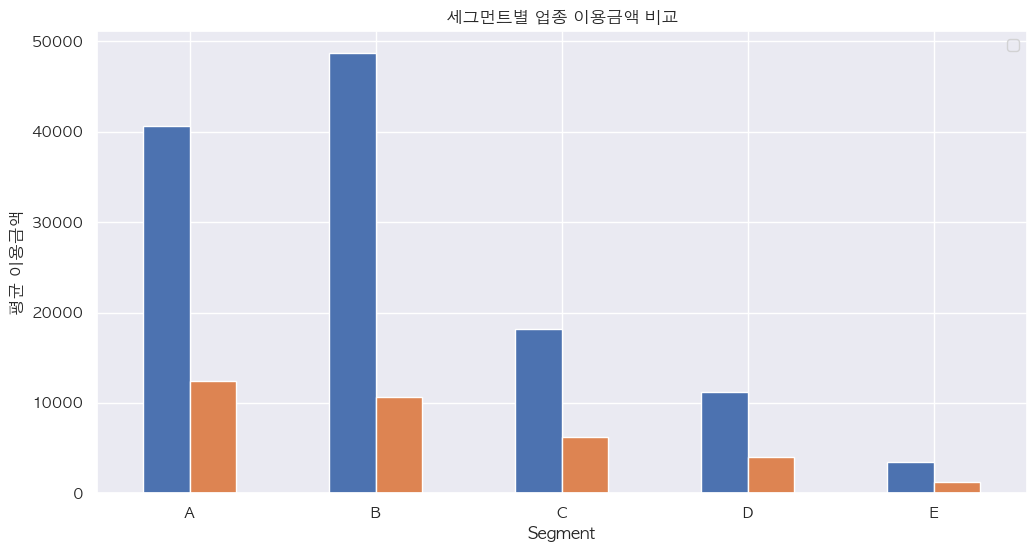

In [55]:
#시각화
df.groupby('Segment')[['_1순위업종_이용금액', '_2순위업종_이용금액']].mean().plot(kind='bar')
plt.title("세그먼트별 업종 이용금액 비교")
plt.ylabel("평균 이용금액")
plt.xticks(rotation=0)
plt.show()

- 업종 이용금액이 B>A>C>D>E

가설1) 업종 이용금액이 높은 B가 카드 이용금액도 높을 것이다

## 세그먼트별 카드 이용금액

In [59]:
df.groupby('Segment')[ '_1순위업종_이용금액'].mean()

Segment
A    40683.477366
B    48690.555556
C    18209.468211
D    11164.637126
E     3445.341962
Name: _1순위업종_이용금액, dtype: float64

- 이용금액 역시 B>A>C>D>E 

## 2. 세그먼트별 일시불, 할부, 무이자 등 결제 유형 파악하기

In [62]:
df.columns

Index(['ID', 'Segment', '카드이용한도금액', '정상청구원금_B0M', '입회경과개월수_신용',
       '이용금액_R3M_신용체크', '_1순위카드이용금액', '최대이용금액_일시불_R12M', '정상입금원금_B0M', '이용금액대',
       '월중평잔', '이용금액_일시불_B0M', '최대이용금액_할부_R12M', '이용금액_R3M_신용', '쇼핑_도소매_이용금액',
       '이용금액_오프라인_R6M', '이용금액_할부_R12M', '잔액_신판ca최대한도소진율_r6m', '최종이용일자_CA',
       '연체입금원금_B0M', '이용금액_CA_R12M', '최종이용일자_할부', 'CL이자율_할인전', '_2순위쇼핑업종_이용금액',
       '_1순위업종_이용금액', '이용금액_할부_무이자_R3M', '이용금액_할부_무이자_B0M', 'CA이자율_할인전',
       '잔액_할부_B0M', '_2순위업종_이용금액', '최종이용일자_체크', 'Recency', 'Monetary'],
      dtype='object')

## a.무이자 관련

In [64]:
usage_i = ['이용금액_할부_무이자_B0M','이용금액_할부_무이자_R3M','이용금액_할부_R12M', '최대이용금액_할부_R12M']

In [65]:
i_mean = df.groupby('Segment')[usage_i].mean()
i_mean

,이용금액_할부_무이자_B0M,이용금액_할부_무이자_R3M,이용금액_할부_R12M,최대이용금액_할부_R12M
Segment,,,,
A,2730.299383,8963.065844,54314.278807,17770.575103
B,5020.645833,15611.430556,81920.993056,22409.743056
C,1143.455130,3709.961400,21116.036476,9001.306443
D,692.932299,2318.328391,14303.873933,6435.402540
E,192.250766,717.709296,4765.238647,2790.817292


- 마찬가지로 B>A>C>D>E

# ---------------

## b.일시불 관련

In [69]:
usage_paying =  ['최대이용금액_일시불_R12M', '이용금액_일시불_B0M']

In [70]:
df.groupby('Segment')[usage_paying].mean()

,최대이용금액_일시불_R12M,이용금액_일시불_B0M
Segment,,
A,67452.723251,19907.425926
B,47270.500000,18011.104167
C,31902.700925,11701.737401
D,17728.708354,7406.559394
E,5682.917780,2340.228270


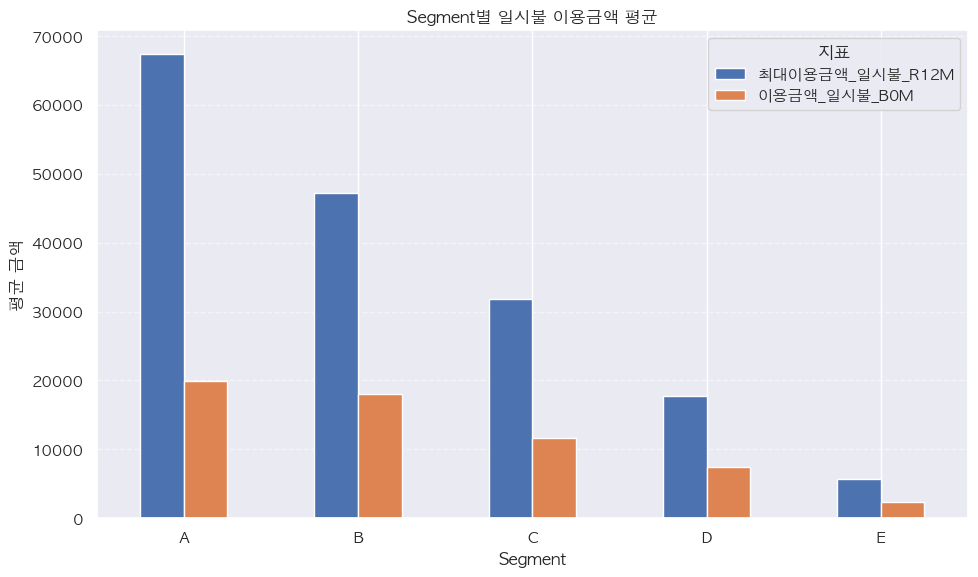

In [71]:
# 시각화
grouped = df.groupby('Segment')[usage_paying].mean()
grouped.plot(kind='bar', figsize=(10,6))

# 그래프 꾸미기
plt.title('Segment별 일시불 이용금액 평균')
plt.ylabel('평균 금액')
plt.xlabel('Segment')
plt.xticks(rotation=0)
plt.legend(title='지표')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


->  `최대이용금액_일시불_R12M`,`이용금액_일시불_BOM` 모두 A>B>C>D>E
- Segment A는 과거 1년간 최대 이용금액도 가장 높고, 현재 월 이용금액도 가장 높음 → 고액 일시불 사용 고객.
- Segment B는 A보단 낮지만 전반적으로 높은 편 → 꾸준한 고액 이용 고객일 가능성 높음 
- Segment E는 모든 항목에서 가장 낮음 → 일시불 이용도가 매우 낮은 고객.